In [3]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset, Dataset


import cv2

from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import torch.nn as nn

import os, gc

from datasets import load_dataset

In [4]:
import os
import sys

from datasets import load_dataset
sys.path.append('/kaggle/input/datasets/iristhomas2507/utility')
import utils as u

In [5]:
import os

print(os.path.exists('/kaggle/input/datasets/iristhomas2507/unet-binary/best_model_fold_0.pth'))

True


In [6]:
dataset = load_dataset("RationAI/PanNuke")

print(dataset)

README.md: 0.00B [00:00, ?B/s]

data/fold1-00000-of-00001.parquet:   0%|          | 0.00/280M [00:00<?, ?B/s]

data/fold2-00000-of-00001.parquet:   0%|          | 0.00/264M [00:00<?, ?B/s]

data/fold3-00000-of-00001.parquet:   0%|          | 0.00/289M [00:00<?, ?B/s]

Generating fold1 split:   0%|          | 0/2656 [00:00<?, ? examples/s]

Generating fold2 split:   0%|          | 0/2523 [00:00<?, ? examples/s]

Generating fold3 split:   0%|          | 0/2722 [00:00<?, ? examples/s]

DatasetDict({
    fold1: Dataset({
        features: ['image', 'instances', 'categories', 'tissue'],
        num_rows: 2656
    })
    fold2: Dataset({
        features: ['image', 'instances', 'categories', 'tissue'],
        num_rows: 2523
    })
    fold3: Dataset({
        features: ['image', 'instances', 'categories', 'tissue'],
        num_rows: 2722
    })
})


In [7]:
path0 = "/kaggle/input/datasets/iristhomas2507/unet-binary/best_model_fold_0.pth" 
path1 = "/kaggle/input/datasets/iristhomas2507/unet-binary/best_model_fold_1.pth" 

In [8]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================
# LOAD MODEL
# =========================
def load_model(model, path):
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model


# =========================
# METRICS
# =========================
def compute_metrics(preds, targets, eps=1e-6):
    preds = preds.view(-1)
    targets = targets.view(-1)

    TP = (preds * targets).sum()
    FP = (preds * (1 - targets)).sum()
    FN = ((1 - preds) * targets).sum()
    TN = ((1 - preds) * (1 - targets)).sum()

    dice = (2 * TP + eps) / (2 * TP + FP + FN + eps)
    iou = (TP + eps) / (TP + FP + FN + eps)
    precision = (TP + eps) / (TP + FP + eps)
    recall = (TP + eps) / (TP + FN + eps)
    accuracy = (TP + TN + eps) / (TP + TN + FP + FN + eps)

    return dice.item(), iou.item(), precision.item(), recall.item(), accuracy.item()


# =========================
# EVALUATION
# =========================
def evaluate(model, dataloader, threshold=0.5):
    model.eval()

    dice_list, iou_list, prec_list, rec_list, acc_list = [], [], [], [], []

    with torch.no_grad():
        for images, masks in tqdm(dataloader):

            images = images.to(device)
            masks = masks.to(device).float()

            logits = model(images)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            d, i, p, r, a = compute_metrics(preds, masks)

            dice_list.append(d)
            iou_list.append(i)
            prec_list.append(p)
            rec_list.append(r)
            acc_list.append(a)

    return {
        "dice": np.mean(dice_list),
        "iou": np.mean(iou_list),
        "precision": np.mean(prec_list),
        "recall": np.mean(rec_list),
        "accuracy": np.mean(acc_list),
    }


# =========================
# SAVE PREDICTIONS
# =========================
def save_predictions(model, dataloader, save_dir="predictions", threshold=0.5):
    os.makedirs(save_dir, exist_ok=True)

    model.eval()
    idx = 0

    with torch.no_grad():
        for images, _ in tqdm(dataloader):

            images = images.to(device)

            probs = torch.sigmoid(model(images))
            preds = (probs > threshold).float()

            for i in range(preds.shape[0]):
                vutils.save_image(preds[i], f"{save_dir}/pred_{idx}.png")
                idx += 1



# VISUALIZATION (SIDE BY SIDE)

def visualize_predictions(model, dataloader, num_samples=5, threshold=0.5):
    model.eval()
    shown = 0

    with torch.no_grad():
        for images, masks in dataloader:

            images = images.to(device)

            probs = torch.sigmoid(model(images))
            preds = (probs > threshold).float()

            for i in range(images.shape[0]):

                if shown >= num_samples:
                    return

                img = images[i].cpu().permute(1,2,0).numpy()
                gt = masks[i].cpu().squeeze().numpy()
                pred = preds[i].cpu().squeeze().numpy()

                plt.figure(figsize=(12,4))

                plt.subplot(1,3,1)
                plt.title("Image")
                plt.imshow(img)
                plt.axis('off')

                plt.subplot(1,3,2)
                plt.title("Ground Truth")
                plt.imshow(gt, cmap='gray')
                plt.axis('off')

                plt.subplot(1,3,3)
                plt.title("Prediction")
                plt.imshow(pred, cmap='gray')
                plt.axis('off')

                plt.show()

                shown += 1



# OVERLAY VISUALIZATION

def overlay_visualization(model, dataloader, num_samples=5, threshold=0.5):
    model.eval()
    shown = 0

    with torch.no_grad():
        for images, masks in dataloader:

            images = images.to(device)

            probs = torch.sigmoid(model(images))
            preds = (probs > threshold).float()

            for i in range(images.shape[0]):

                if shown >= num_samples:
                    return

                img = images[i].cpu().permute(1,2,0).numpy()
                gt = masks[i].cpu().squeeze().numpy()
                pred = preds[i].cpu().squeeze().numpy()

                plt.figure(figsize=(6,6))

                plt.imshow(img)
                
                # Ground truth in GREEN
                plt.imshow(np.ma.masked_where(gt == 0, gt), cmap='Greens', alpha=0.5)
                
                # Prediction in RED
                plt.imshow(np.ma.masked_where(pred == 0, pred), cmap='Reds', alpha=0.5)

                plt.title("Overlay (Green=GT, Red=Pred)")
                plt.axis('off')
                plt.show()

                shown += 1




In [9]:
def process_fold(hf_dataset, fold_name):
    print(f"\nProcessing {fold_name}")
    print("Number of samples:", len(hf_dataset))

    images = []
    masks = []

    for i in tqdm(range(len(hf_dataset))):
        sample = hf_dataset[i]

        img = preprocess_image(sample["image"])
        msk = preprocess_mask(sample["instances"])

        images.append(img)
        masks.append(msk)

    
    images = np.stack(images, axis=0)
    masks = np.stack(masks, axis=0)
    print(f"{fold_name} done:")
    print("Images:", images.shape)
    print("Masks:", masks.shape)
    print("Mask values:", np.unique(masks))

    return images, masks


def preprocess_all_folds(dataset):
    folds = []
    #fold 3 is test
    for fold_name in ["fold3"]:
    #for fold_name in ["fold1"]:
        imgs, msks = process_fold(dataset[fold_name], fold_name)
        folds.append((imgs, msks))

    return folds

In [10]:
def preprocess_mask(instances):
    instances = np.array(instances)

    #completely empty (no nuclei at all)
    if instances.size == 0 or instances.ndim == 1:
        binary_mask = np.zeros((256, 256), dtype=np.uint8)

    else:
        #Normal case
        binary_mask = np.any(instances > 0, axis=0)
        binary_mask = binary_mask.astype(np.uint8)

    #Safety check (but don't crash blindly)
    if binary_mask.shape != (256, 256):
        print("\nUnexpected mask shape")
        print("Raw shape:", instances.shape)
        print("After merge:", binary_mask.shape)
        print("Unique:", np.unique(binary_mask))

        # Instead of crashing → fix it
        binary_mask = np.zeros((256, 256), dtype=np.uint8)

    # add channel
    binary_mask = np.expand_dims(binary_mask, axis=0)

    return binary_mask

In [11]:
def preprocess_image(image):
    #print("\n[IMAGE PREPROCESSING]")
    image = np.array(image)
    #print("Original shape:", image.shape)
    #print("Original dtype:", image.dtype)

    # Normalize to [0,1]
    image = image.astype(np.float32) / 255.0

    # Convert HWC → CHW
    image = np.transpose(image, (2, 0, 1))

    #print("Processed shape (CHW):", image.shape)
    #print("Min/Max values:", image.min(), image.max())

    return image




In [12]:
processed_folds = preprocess_all_folds(dataset)
test_images,test_masks=processed_folds[0]



Processing fold3
Number of samples: 2722


100%|██████████| 2722/2722 [00:35<00:00, 77.68it/s] 


fold3 done:
Images: (2722, 3, 256, 256)
Masks: (2722, 1, 256, 256)
Mask values: [0 1]


In [17]:
test_images = torch.stack([torch.tensor(x) for x in test_images])
test_masks  = torch.stack([torch.tensor(x) for x in test_masks])

100%|██████████| 341/341 [43:57<00:00,  7.73s/it]



===== TEST RESULTS (Fold 3) =====
DICE: 0.8167
IOU: 0.6966
PRECISION: 0.8047
RECALL: 0.8377
ACCURACY: 0.9404


100%|██████████| 341/341 [44:41<00:00,  7.86s/it]


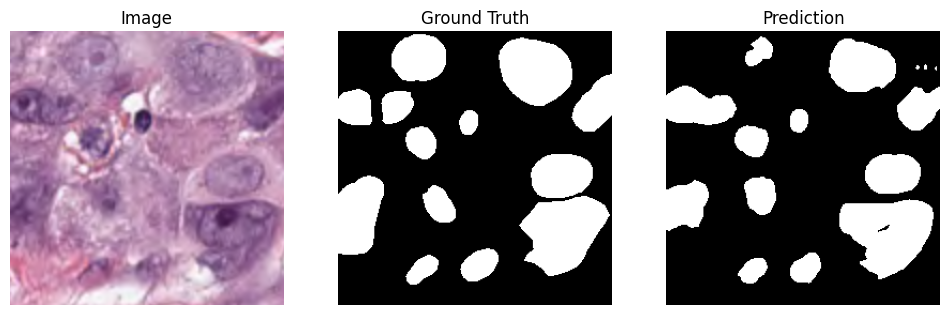

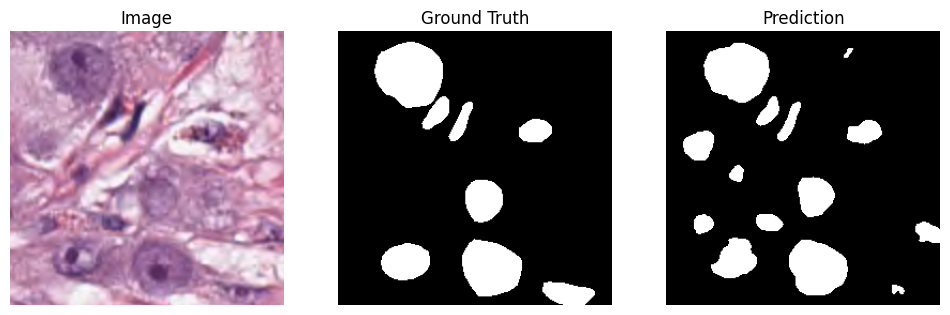

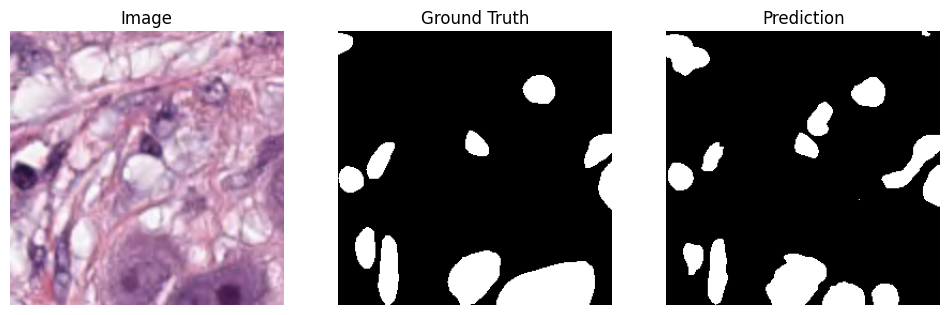

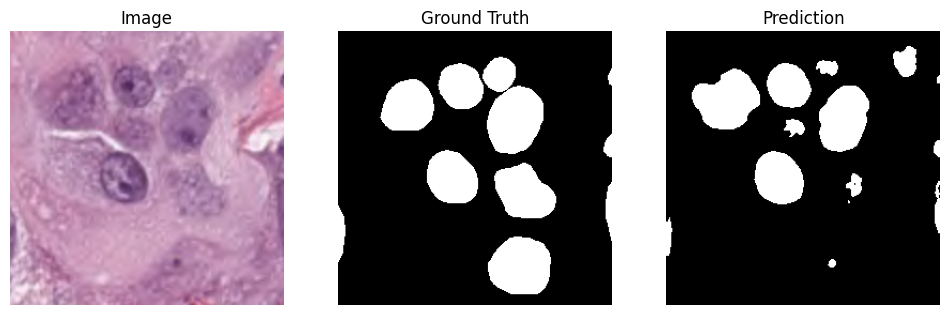

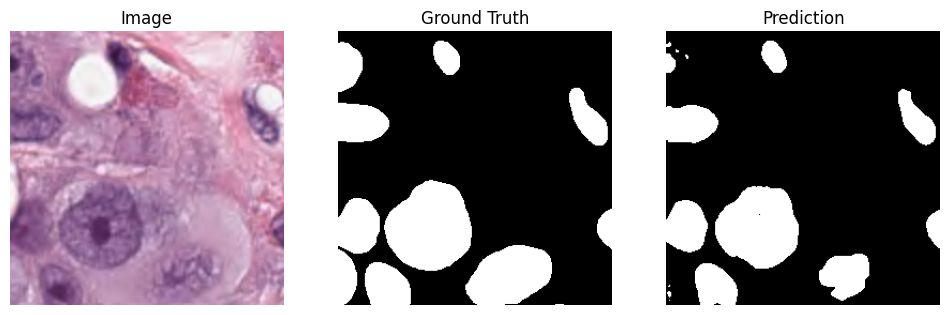

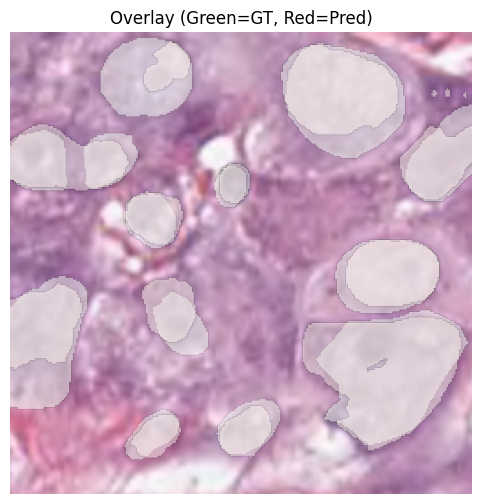

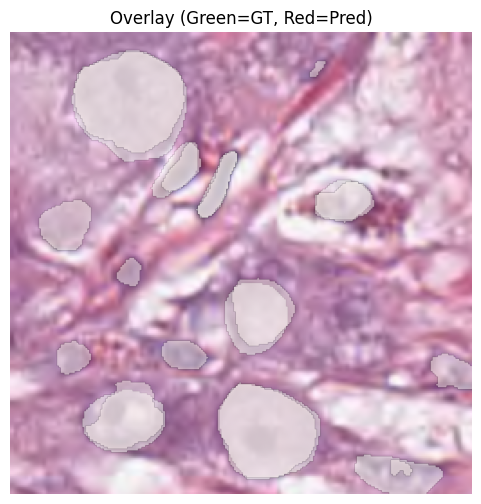

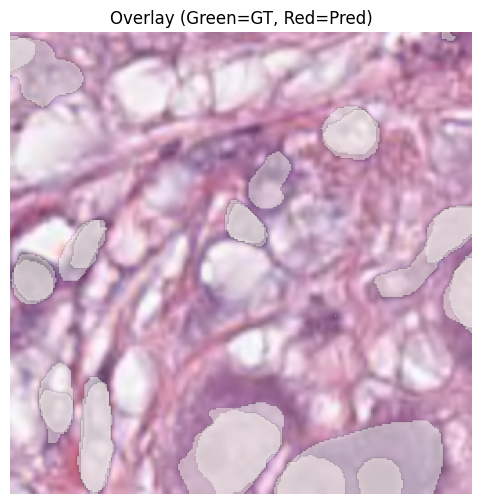

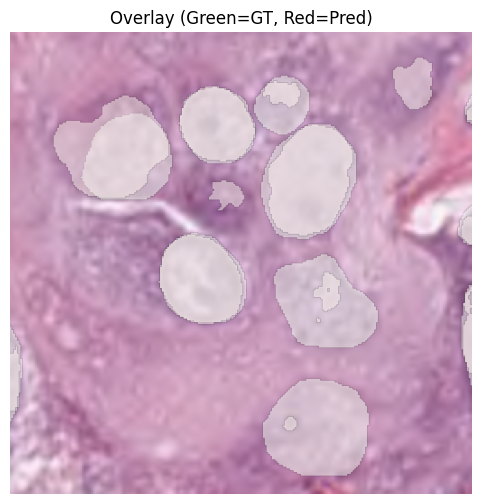

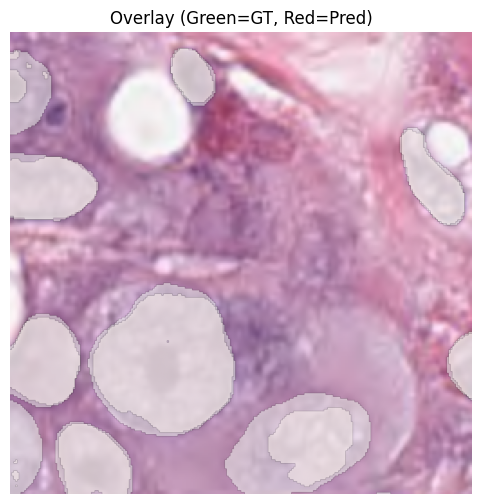

In [19]:
# =========================
# MAIN EXECUTION for model 0
# =========================

# 1. Initialize model
model = u.unet(1) 

# 2. Load weights
model = load_model(model, path0)

# 3. Prepare fold3 test loader
test_dataset = TensorDataset(test_images, test_masks)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# 4. Evaluate
metrics = evaluate(model, test_loader)

print("\n===== TEST RESULTS, model0, (Fold 3) =====")
for k, v in metrics.items():
    print(f"{k.upper()}: {v:.4f}")

# 5. Save predictions
save_predictions(model, test_loader)

# 6. Visualize
visualize_predictions(model, test_loader, num_samples=5)


overlay_visualization(model, test_loader, num_samples=5)

In [ ]:


# 2. Load weights
model1 = load_model(model, path1)

# 3. Prepare fold3 test loader
test_dataset = TensorDataset(test_images, test_masks)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# 4. Evaluate
metrics1 = evaluate(model1, test_loader)

print("\n===== TEST RESULTS (Fold 3) =====")
for k, v in metrics.items():
    print(f"{k.upper()}: {v:.4f}")

# 5. Save predictions
save_predictions(model1, test_loader)

# 6. Visualize
visualize_predictions(model1, test_loader, num_samples=5)


overlay_visualization(model1, test_loader, num_samples=5)

 40%|███▉      | 136/341 [18:00<26:49,  7.85s/it]